# Single Asset Backtest with ml4t-backtest

**Docker image**: `ml4t`

This notebook introduces the **ml4t-backtest** event-driven backtesting engine.
We implement the same RSI mean-reversion strategy as notebook 03 (VectorBT),
demonstrating how event-driven backtesting more closely mirrors live trading.

## When to Use ml4t-backtest vs VectorBT

| Aspect | ml4t-backtest | VectorBT |
|--------|---------------|----------|
| **Best for** | Production strategies, complex logic | Rapid prototyping, parameter sweeps |
| **Execution model** | Event-driven (bar-by-bar) | Vectorized (all-at-once) |
| **Code reuse** | Strategy code → live trading | Backtest-only code |
| **Speed** | Slower (realistic) | Fast (vectorized) |
| **Position management** | Full order lifecycle | Simplified fills |
| **Use case** | Final validation, deployment | Early exploration, optimization |

**Rule of Thumb**: Use VectorBT for exploration and optimization, then validate
with ml4t-backtest before deployment.

**Learning Objectives:**
1. Implement a production-style `Strategy` class with `on_data` callbacks.
2. Run an event-driven backtest with realistic execution timing and costs.
3. Interpret differences between vectorized and event-driven backtest outputs.

**Book Reference:** Chapter 16, Sections 16.3-16.5 (simulation workflow and reporting).

**Prerequisites:** Complete [`03_single_asset_vectorbt`](03_single_asset_vectorbt.ipynb) first.

## Key Concepts Introduced

1. **Strategy class**: Encapsulates trading logic in `on_data()` method
2. **DataFeed**: Combines OHLCV prices with context data (indicators)
3. **Engine**: Orchestrates backtest execution with commission/slippage
4. **Broker**: Manages orders, positions, and portfolio state
5. **ExecutionMode**: Controls order fill timing (same-bar vs next-bar)

## Strategy: RSI Mean Reversion on BTC

- **Long Entry**: RSI < 30 (oversold)
- **Exit**: RSI > 70 (overbought)
- **Position Size**: 95% of capital per trade
- **Transaction Costs**: 10 bps commission + 5 bps slippage

## Setup

In [1]:
"""Single Asset Backtest with ml4t-backtest — event-driven RSI strategy matching the VectorBT implementation."""

import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    OrderSide,
    OrderType,
    Strategy,
)
from ml4t.backtest.analytics import MAEMFEAnalyzer, TradeAnalyzer
from ml4t.backtest.sessions import SessionConfig, compute_session_pnl
from plotly.subplots import make_subplots

from data import load_crypto_perps
from utils.paths import get_output_dir

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2020-01-01"
END_DATE = "2024-01-01"
INITIAL_CASH = 100_000

## 1. Data Acquisition

We load BTC/USDT data from the crypto perpetuals dataset and resample
8-hourly bars to daily frequency.

In [3]:
# Backtest cost parameters
FEES = 0.001  # 10 bps per trade
SLIPPAGE = 0.0005  # 5 bps slippage

# RSI parameters
RSI_PERIOD = 14
RSI_LOWER = 30  # Oversold threshold
RSI_UPPER = 70  # Overbought threshold
POSITION_SIZE = 0.95  # 95% of capital per trade

In [4]:
# Load BTC data from local crypto dataset and resample to daily bars
_crypto = load_crypto_perps()
btc_df = (
    _crypto.filter(
        (pl.col("symbol") == "BTCUSDT")
        & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
        & (pl.col("timestamp") < pl.lit(END_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
    )
    .sort("timestamp")
    .with_columns(pl.col("timestamp").dt.replace_time_zone(None))
    .group_by_dynamic("timestamp", every="1d")
    .agg(
        pl.col("open").first(),
        pl.col("high").max(),
        pl.col("low").min(),
        pl.col("close").last(),
        pl.col("volume").sum(),
    )
    .with_columns(pl.lit("BTCUSDT").alias("symbol"))
)

prices_df = btc_df
print(f"Loaded {len(prices_df):,} daily bars from local crypto dataset")
print(f"Date range: {prices_df['timestamp'].min()} to {prices_df['timestamp'].max()}")

Loaded 1,461 daily bars from local crypto dataset
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00


## 2. RSI Indicator Calculation

Compute RSI using the Wilder smoothing method (same as VectorBT).

In [5]:
def compute_rsi(close: pl.Series, period: int = 14) -> pl.Series:
    """Compute RSI using Wilder's smoothing method."""
    delta = close.diff()
    # Note: Use float literals (0.0) to ensure consistent Polars types
    gain = delta.clip(lower_bound=0.0).fill_null(0.0)
    loss = (-delta).clip(lower_bound=0.0).fill_null(0.0)

    # Wilder's smoothed moving average (exponential with alpha = 1/period)
    avg_gain = gain.ewm_mean(span=period * 2 - 1, adjust=False)
    avg_loss = loss.ewm_mean(span=period * 2 - 1, adjust=False)

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


# Compute RSI and add to context
rsi_values = compute_rsi(prices_df["close"], RSI_PERIOD)

# Create context DataFrame with RSI
context_df = prices_df.select(["timestamp"]).with_columns(rsi_values.alias("rsi"))

rsi_valid = context_df["rsi"].drop_nans()
print(f"RSI Statistics ({len(rsi_valid)}/{len(context_df)} valid):")
print(f"  Mean: {rsi_valid.mean():.1f}")
print(f"  Std:  {rsi_valid.std():.1f}")
print(f"  Min:  {rsi_valid.min():.1f}")
print(f"  Max:  {rsi_valid.max():.1f}")

RSI Statistics (1460/1461 valid):
  Mean: 53.2
  Std:  14.0
  Min:  0.0
  Max:  89.5


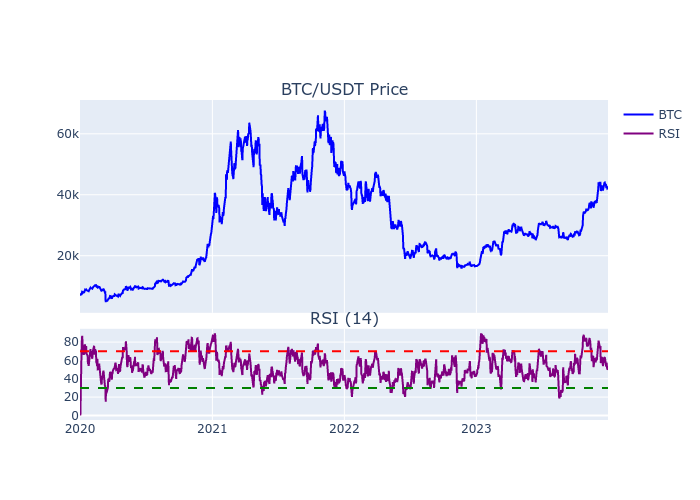

In [6]:
# Visualize price and RSI
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.7, 0.3],
    subplot_titles=["BTC/USDT Price", "RSI (14)"],
)

fig.add_trace(
    go.Scatter(
        x=prices_df["timestamp"].to_list(),
        y=prices_df["close"].to_list(),
        name="BTC",
        line=dict(color="blue"),
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=context_df["timestamp"].to_list(),
        y=context_df["rsi"].to_list(),
        name="RSI",
        line=dict(color="purple"),
    ),
    row=2,
    col=1,
)

# Add RSI threshold lines
fig.add_hline(y=RSI_LOWER, line_dash="dash", line_color="green", row=2, col=1)
fig.add_hline(y=RSI_UPPER, line_dash="dash", line_color="red", row=2, col=1)

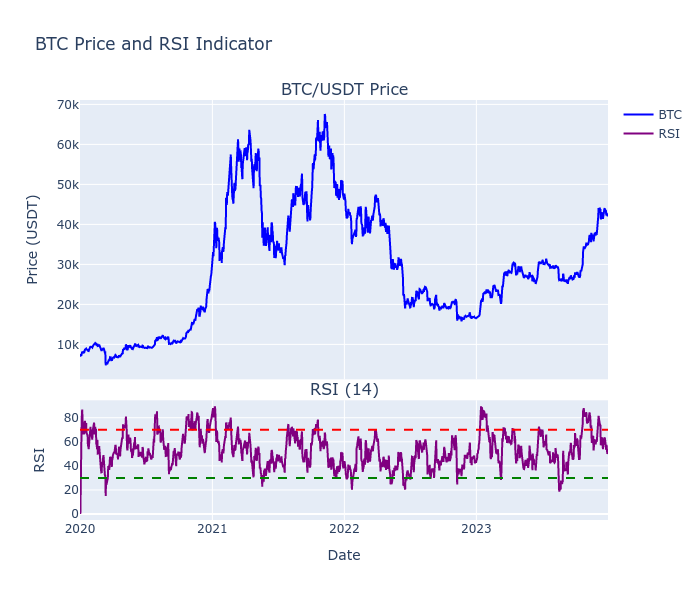

In [7]:
# Layout and display
fig.update_layout(
    height=600,
    title="BTC Price and RSI Indicator",
    showlegend=True,
    xaxis2_title="Date",
    yaxis_title="Price (USDT)",
    yaxis2_title="RSI",
)
fig.show()

## 3. Define Strategy Class

The `Strategy` class is the heart of ml4t-backtest. You subclass it and implement
the `on_data()` method, which is called for each bar during the backtest.

### Strategy Best Practices

1. **Initialize parameters in `__init__`**: Pass strategy parameters (thresholds,
   lookbacks) to `__init__`, not hard-coded in `on_data()`.

2. **Use `broker.get_position()` for position checks**: Returns `None` if no position,
   or a `Position` object with `quantity`, `entry_price`, `unrealized_pnl`.

3. **Access context data via `context.get()`**: Indicators precomputed and passed
   via `context_df` are available here. Always check for `None`/`NaN`.

4. **Submit orders via `broker.submit_order()`**: Pass `asset`, `quantity`,
   `side`, and `order_type` directly. The broker creates the Order internally.

5. **Handle data availability gracefully**: Early bars may lack history for
   indicators. Check before trading.

### RSI Mean Reversion Logic

- **Enter Long**: RSI < 30 (oversold, expect mean reversion bounce)
- **Exit Long**: RSI > 70 (overbought, take profit)

In [8]:
class RSIMeanReversionStrategy(Strategy):
    """RSI Mean Reversion Strategy - Canonical ml4t-backtest Pattern.

    This strategy demonstrates the standard ml4t-backtest Strategy class structure:
    - __init__: Initialize parameters and any state variables
    - on_data: Trading logic called for each bar

    Strategy Logic:
    - Long Entry: RSI < lower threshold (oversold)
    - Exit: RSI > upper threshold (overbought)

    Attributes:
        rsi_lower: RSI threshold for long entry (default: 30)
        rsi_upper: RSI threshold for exit (default: 70)
        position_size: Fraction of capital to deploy (default: 0.95)
    """

    def __init__(
        self,
        rsi_lower: float = 30,
        rsi_upper: float = 70,
        position_size: float = 0.95,
    ):
        """Initialize strategy parameters.

        Args:
            rsi_lower: RSI level below which to enter long (oversold).
            rsi_upper: RSI level above which to exit (overbought).
            position_size: Fraction of available cash to use per trade.
        """
        # Store strategy parameters as instance attributes
        self.rsi_lower = rsi_lower
        self.rsi_upper = rsi_upper
        self.position_size = position_size

    def on_data(self, timestamp, data, context, broker):
        """Called for each bar during backtest.

        This is the main trading logic method. It receives:
        - timestamp: Current bar's datetime
        - data: Dict of {asset: {open, high, low, close, volume}}
        - context: Dict of precomputed indicators (from context_df)
        - broker: Interface to submit orders and query positions

        The broker provides:
        - broker.cash: Available cash balance
        - broker.equity: Total portfolio value (cash + positions)
        - broker.get_position(asset): Returns Position or None
        - broker.submit_order(order): Submit an Order for execution
        """
        # ============================================================
        # Step 1: Get indicator value from context
        # ============================================================
        # Context contains columns from context_df, keyed by column name.
        # Always check for None/NaN - early bars may lack indicator values.
        rsi = context.get("rsi")
        if rsi is None or np.isnan(rsi):
            return  # Skip bar - RSI not yet available

        # ============================================================
        # Step 2: Check current position state
        # ============================================================
        # broker.get_position() returns None if no position, or a Position object
        # with attributes: quantity, entry_price, market_value, unrealized_pnl
        asset = "BTCUSDT"
        position = broker.get_position(asset)
        is_in_position = position is not None and position.quantity > 0

        # ============================================================
        # Step 3: Get current price from data
        # ============================================================
        # data is a dict of {asset: bar_dict} where bar_dict has OHLCV keys
        asset_data = data.get(asset)
        if asset_data is None:
            return  # Skip - no data for this asset on this bar
        current_price = asset_data["close"]

        # ============================================================
        # Step 4: Apply trading logic
        # ============================================================
        if not is_in_position and rsi < self.rsi_lower:
            # ENTRY SIGNAL: RSI oversold → expect mean reversion bounce
            # Crypto trades fractional; we keep eight-decimal precision so the
            # exposure matches VectorBT's ``size=0.95, size_type='percent'``
            # convention in NB03 — avoids the integer-rounding wedge that would
            # show up as a third (avoidable) source of NB03 <-> NB04 divergence
            # on top of timing and RSI seeding.
            available_cash = broker.cash * self.position_size
            quantity = round(available_cash / current_price, 8)

            if quantity > 0:
                # Submit market buy order
                # API: broker.submit_order(asset, quantity, side, order_type)
                broker.submit_order(
                    asset,
                    quantity,
                    side=OrderSide.BUY,
                    order_type=OrderType.MARKET,
                )

        elif is_in_position and rsi > self.rsi_upper:
            # EXIT SIGNAL: RSI overbought → take profit
            # Sell entire position
            broker.submit_order(
                asset,
                position.quantity,
                side=OrderSide.SELL,
                order_type=OrderType.MARKET,
            )

## 4. Run Backtest

To run a backtest, we need three components:

1. **DataFeed**: Provides OHLCV data and context (indicators) bar-by-bar
2. **Strategy**: Our trading logic (implemented above)
3. **Engine**: Orchestrates execution, applies costs, tracks portfolio

### Execution Mode

The `execution_mode` parameter controls order fill timing:

- `SAME_BAR`: Orders fill at the close of the signal bar (unrealistic but fast)
- `NEXT_BAR`: Orders fill at the open of the next bar (realistic)

For production validation, always use `NEXT_BAR` to avoid look-ahead bias.

In [9]:
# -----------------------------------------------------------------------------
# Step 1: Create DataFeed
# -----------------------------------------------------------------------------
# DataFeed combines OHLCV prices with context data (indicators).
# - prices_df: Required columns: timestamp, asset, open, high, low, close, volume
# - context_df: Optional. Columns are passed to strategy via context dict.
#   Must have 'timestamp' column aligned with prices_df.
feed = DataFeed(
    prices_df=prices_df,
    context_df=context_df,
)

# -----------------------------------------------------------------------------
# Step 2: Instantiate Strategy
# -----------------------------------------------------------------------------
# Pass strategy parameters to __init__. These can be optimized later.
strategy = RSIMeanReversionStrategy(
    rsi_lower=RSI_LOWER,
    rsi_upper=RSI_UPPER,
    position_size=POSITION_SIZE,
)

# -----------------------------------------------------------------------------
# Step 3: Configure and Create Engine
# -----------------------------------------------------------------------------
# BacktestConfig centralizes all behavioral settings — execution timing,
# transaction costs, position sizing rules, and more. The Engine reads
# these settings and wires them into the Broker automatically.
config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,  # Realistic: fill at next bar open
    commission_rate=FEES,  # 10 bps per trade (percentage of trade value)
    slippage_rate=SLIPPAGE,  # 5 bps market impact
)

engine = Engine(feed=feed, strategy=strategy, config=config)

In [10]:
# Run backtest
print("Running backtest...")
results = engine.run()

Running backtest...


**Portfolio performance summary** (RSI mean reversion via ml4t-backtest):

In [11]:
pl.DataFrame(
    {
        "metric": [
            "Final value ($)",
            "Total return (%)",
            "Sharpe ratio",
            "Max drawdown (%)",
            "Total trades",
            "Win rate (%)",
        ],
        "value": [
            float(results["final_value"]),
            float(results["total_return_pct"]),
            float(results["sharpe"]),
            float(results["max_drawdown_pct"]),
            float(results["num_trades"]),
            float(results.get("win_rate", 0) * 100),
        ],
    }
)

metric,value
str,f64
"""Final value ($)""",188641.342164
"""Total return (%)""",88.641342
"""Sharpe ratio""",0.503859
"""Max drawdown (%)""",45.259479
"""Total trades""",7.0
"""Win rate (%)""",71.428571


## 5. Daily Returns Artifact (Calendar vs Session Alignment)

In [12]:
# Build daily return artifact from equity curve (calendar-day aggregation)
ec = results["equity"]
equity_df = pl.DataFrame(
    {
        "timestamp": pl.Series("timestamp", ec.timestamps, dtype=pl.Datetime, strict=False),
        "equity": pl.Series("equity", ec.values, dtype=pl.Float64, strict=False),
    }
).sort("timestamp")

calendar_daily = (
    equity_df.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))
    .group_by("timestamp")
    .agg(
        open_equity=pl.col("equity").first(),
        close_equity=pl.col("equity").last(),
    )
    .sort("timestamp")
)
calendar_daily = calendar_daily.with_columns(
    ((pl.col("close_equity") - pl.col("close_equity").shift(1)) / pl.col("close_equity").shift(1))
    .fill_null(0.0)
    .alias("daily_return")
)

OUTPUT_DIR = get_output_dir(16, "single_asset_ml4t_backtest")
daily_returns_path = OUTPUT_DIR / "daily_returns_calendar.parquet"
calendar_daily.select(["timestamp", "daily_return"]).write_parquet(daily_returns_path)
print(f"Saved daily returns artifact: {daily_returns_path}")

# CME session-aligned demo (overnight session starts at 17:00 CT)
cme_equity_demo = [
    (datetime(2024, 1, 8, 16, 30), 100_000.0),  # Monday session (before 17:00)
    (datetime(2024, 1, 8, 17, 30), 100_400.0),  # Tuesday session (after 17:00)
    (datetime(2024, 1, 9, 16, 0), 100_900.0),  # Tuesday close
]
session_demo = compute_session_pnl(
    cme_equity_demo,
    SessionConfig(calendar="CME_Equity", timezone="America/Chicago"),
)

Saved daily returns artifact: 16_strategy_simulation/output/single_asset_ml4t_backtest/daily_returns_calendar.parquet


CME session-aligned daily returns (3-bar demo crossing the 17:00 CT boundary):

In [13]:
session_demo.select(["session_date", "return_pct"])

session_date,return_pct
datetime[μs],f64
2024-01-08 00:00:00,0.0
2024-01-09 00:00:00,0.009


Session-aligned aggregation is required for futures because trading sessions
cross calendar boundaries (e.g., CME evening open). For equities/crypto daily
bars, calendar-day aggregation is usually equivalent.

## 6. Analyze Trade Statistics

In [14]:
# Extract and analyze trades
trades = results.get("trades", [])

if trades:
    analyzer = TradeAnalyzer(trades)

    print(f"\nTotal Trades: {analyzer.num_trades}")
    print("\nTrade Statistics:")
    print(f"  Win Rate:       {analyzer.win_rate:.1%}")
    print(f"  Profit Factor:  {analyzer.profit_factor:.2f}")
    print(f"  Payoff Ratio:   {analyzer.payoff_ratio:.2f}")
    print(f"  Avg Trade:      {analyzer.avg_trade:.2%}")
    print(f"  Avg Win:        {analyzer.avg_win:.2%}")
    print(f"  Avg Loss:       {analyzer.avg_loss:.2%}")
    print(f"  Largest Win:    {analyzer.largest_win:.2%}")
    print(f"  Largest Loss:   {analyzer.largest_loss:.2%}")
    print(f"  Expectancy:     {analyzer.expectancy:.2%}")
    print(f"  Avg Bars Held:  {analyzer.avg_bars_held:.1f}")

    # Show first few trades
    print("\nFirst 5 Trades:")
    for i, trade in enumerate(trades[:5]):
        print(
            f"  {i + 1}. {trade.entry_time.date()} -> {trade.exit_time.date()} | "
            f"P&L: ${trade.pnl:,.2f} ({trade.pnl_percent * 100:.1f}%)"
        )
else:
    print("No trades executed")


Total Trades: 7

Trade Statistics:
  Win Rate:       71.4%
  Profit Factor:  2.01
  Payoff Ratio:   1.28
  Avg Trade:      15.24%
  Avg Win:        31.07%
  Avg Loss:       -24.33%
  Largest Win:    84.27%
  Largest Loss:   -40.39%
  Expectancy:     15.24%
  Avg Bars Held:  74.9

First 5 Trades:
  1. 2020-01-03 -> 2020-01-07 | P&L: $10,053.16 (11.3%)
  2. 2020-03-13 -> 2020-04-30 | P&L: $84,030.50 (84.3%)
  3. 2021-05-18 -> 2021-07-29 | P&L: $-14,749.54 (-8.3%)
  4. 2022-01-08 -> 2022-03-30 | P&L: $22,924.70 (14.0%)
  5. 2022-05-10 -> 2023-01-12 | P&L: $-73,154.36 (-40.4%)


## 6b. Trade Log and Cost Decomposition

The `BacktestResult` provides structured export methods for downstream analysis:

- `to_trades_dataframe()` → Polars DataFrame with 22 columns per trade
- `result.metrics` → Dictionary of portfolio- and trade-level statistics

The trade DataFrame includes cost decomposition columns that separate
price-move P&L from transaction costs — essential for understanding
whether a strategy's edge survives implementation costs.

In [15]:
# Export trades as a structured DataFrame (Polars — Parquet-ready)
trades_df = results.to_trades_dataframe()
print(f"Trade DataFrame: {trades_df.shape[0]} trades, {trades_df.shape[1]} columns")
print(f"Columns: {trades_df.columns}\n")

# Show key columns including cost decomposition
print(
    trades_df.select(
        [
            "symbol",
            "direction",
            "entry_price",
            "exit_price",
            "pnl",
            "pnl_percent",
            "gross_pnl",
            "cost_drag",
            "exit_reason",
        ]
    ).head(5)
)

Trade DataFrame: 7 trades, 32 columns
Columns: ['symbol', 'entry_time', 'exit_time', 'entry_price', 'exit_price', 'quantity', 'direction', 'pnl', 'pnl_percent', 'bars_held', 'fees', 'exit_slippage', 'mfe', 'mae', 'entry_slippage', 'multiplier', 'entry_quote_mid_price', 'entry_bid_price', 'entry_ask_price', 'entry_spread', 'entry_available_size', 'exit_quote_mid_price', 'exit_bid_price', 'exit_ask_price', 'exit_spread', 'exit_available_size', 'gross_pnl', 'net_return', 'total_slippage_cost', 'cost_drag', 'exit_reason', 'status']

shape: (5, 9)
┌─────────┬───────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ symbol  ┆ direction ┆ entry_pric ┆ exit_pric ┆ … ┆ pnl_perce ┆ gross_pnl ┆ cost_drag ┆ exit_reas │
│ ---     ┆ ---       ┆ e          ┆ e         ┆   ┆ nt        ┆ ---       ┆ ---       ┆ on        │
│ str     ┆ str       ┆ ---        ┆ ---       ┆   ┆ ---       ┆ f64       ┆ f64       ┆ ---       │
│         ┆           ┆ f64        ┆ f64       

In [16]:
# Cost decomposition from result.metrics
m = results.metrics
print("\nCost Decomposition (from result.metrics):")
print(f"  Gross P&L:            ${m['total_gross_pnl']:>12,.2f}")
print(f"  Total Costs:          ${m['total_costs']:>12,.2f}")
print(f"  Net P&L:              ${m['total_return'] * INITIAL_CASH:>12,.2f}")
print(f"  Avg Cost Drag:        {m['avg_cost_drag']:.4%}")
print(f"  Gross Profit Factor:  {m['gross_profit_factor']:.2f}")
print(f"  Net Profit Factor:    {m['profit_factor']:.2f}")


Cost Decomposition (from result.metrics):
  Gross P&L:            $   90,719.21
  Total Costs:          $    3,116.83
  Net P&L:              $   88,641.34
  Avg Cost Drag:        0.3229%
  Gross Profit Factor:  2.04
  Net Profit Factor:    2.01


The `cost_drag` column shows what fraction of each trade's notional value
was consumed by fees and slippage. For BTC with 15 bps total costs,
typical cost drag is ~0.15% per round trip. The `gross_pnl` column strips
out all costs, showing the pure price-move P&L.

This DataFrame persists well as Parquet for downstream analysis with
`ml4t-diagnostic` (trade analytics, MAE/MFE, regime slicing).

## 7. Performance Visualization

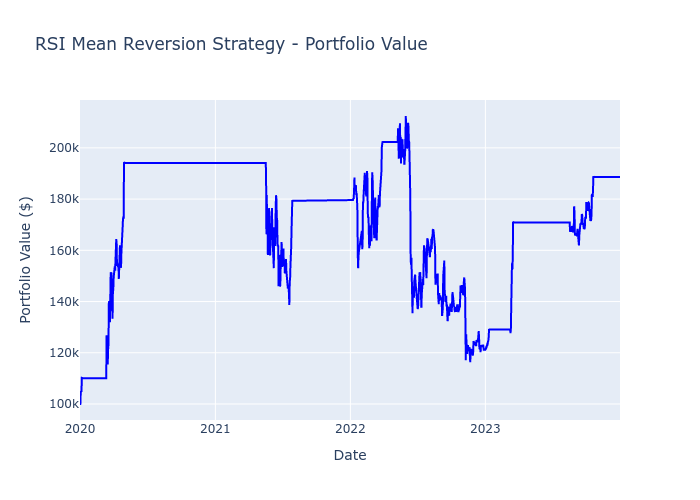

In [17]:
# Plot portfolio value over time
ec = results["equity"]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=ec.timestamps,
        y=ec.values,
        name="Portfolio Value",
        line=dict(color="blue", width=2),
    )
)

fig.update_layout(
    title="RSI Mean Reversion Strategy - Portfolio Value",
    xaxis_title="Date",
    yaxis_title="Portfolio Value ($)",
    height=500,
)
fig.show()

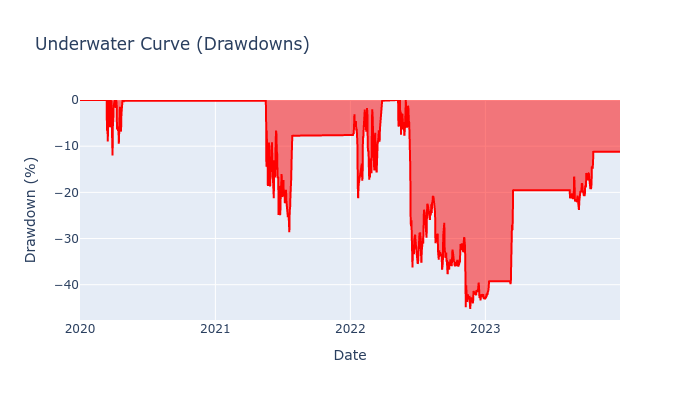

In [18]:
# Plot drawdown
fig_dd = go.Figure()
fig_dd.add_trace(
    go.Scatter(
        x=ec.timestamps,
        y=ec.drawdown_series() * 100,  # Call drawdown_series() method
        name="Drawdown",
        fill="tozeroy",
        line=dict(color="red"),
    )
)

fig_dd.update_layout(
    title="Underwater Curve (Drawdowns)",
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    height=400,
)
fig_dd.show()

## 8. Compare to Buy-and-Hold Benchmark

A strategy should beat buy-and-hold to be worthwhile. Let's compare.

In [19]:
# Create buy-and-hold benchmark
bh_returns = prices_df.with_columns((pl.col("close") / prices_df["close"][0]).alias("cumulative"))
bh_equity = bh_returns["cumulative"].to_numpy() * INITIAL_CASH
bh_total_return = (bh_equity[-1] / INITIAL_CASH - 1) * 100

# Strategy returns
strategy_return = results["total_return_pct"]

**Strategy vs buy-and-hold comparison** (Sharpe and max drawdown for B&H are
computed in NB 03 with full ml4t-diagnostic; here we focus on total return,
trade count, and the strategy's own risk metrics):

In [20]:
pl.DataFrame(
    {
        "metric": ["Total return (%)", "Sharpe ratio", "Max drawdown (%)", "Total trades"],
        "rsi_strategy": [
            float(strategy_return),
            float(results["sharpe"]),
            float(results["max_drawdown_pct"]),
            float(results["num_trades"]),
        ],
        "buy_and_hold": [
            float(bh_total_return),
            float("nan"),
            float("nan"),
            0.0,
        ],
    }
)

metric,rsi_strategy,buy_and_hold
str,f64,f64
"""Total return (%)""",88.641342,487.892858
"""Sharpe ratio""",0.503859,NaN
"""Max drawdown (%)""",45.259479,NaN
"""Total trades""",7.0,0.0


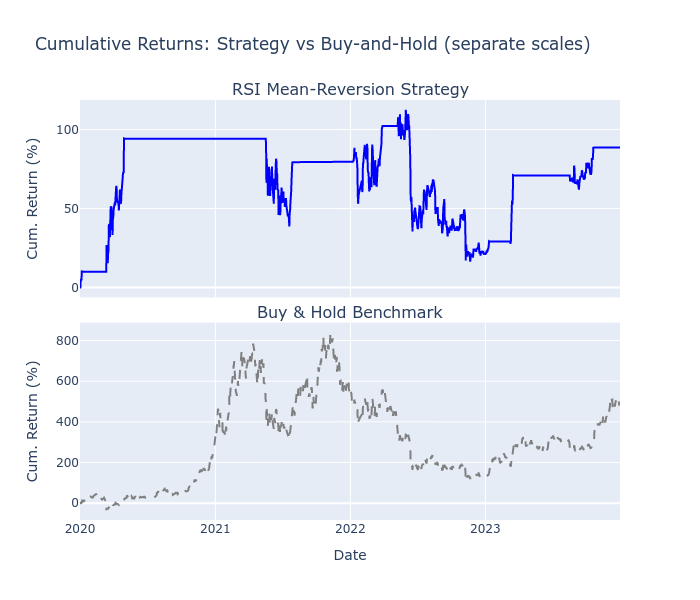

In [21]:
# Plot cumulative returns comparison — separate panels so the order-of-magnitude
# gap (B&H ~800% vs RSI ~80%) does not collapse the strategy line at this scale.
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=("RSI Mean-Reversion Strategy", "Buy & Hold Benchmark"),
)

strategy_cum = (np.array(ec.values) / INITIAL_CASH - 1) * 100
bh_cum = (bh_equity / INITIAL_CASH - 1) * 100

fig.add_trace(
    go.Scatter(
        x=ec.timestamps, y=strategy_cum.tolist(), name="RSI Strategy", line=dict(color="blue")
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=prices_df["timestamp"].to_list(),
        y=bh_cum.tolist(),
        name="Buy & Hold",
        line=dict(color="gray", dash="dash"),
    ),
    row=2,
    col=1,
)
fig.update_yaxes(title_text="Cum. Return (%)", row=1, col=1)
fig.update_yaxes(title_text="Cum. Return (%)", row=2, col=1)
fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_layout(
    title="Cumulative Returns: Strategy vs Buy-and-Hold (separate scales)",
    height=600,
    showlegend=False,
)
fig.show()

## 8. MFE/MAE Analysis

Analyze trade efficiency using Maximum Favorable/Adverse Excursion.

In [22]:
mfe_analyzer = MAEMFEAnalyzer(trades)
levels = mfe_analyzer.optimal_exit_levels()

mfe_mae_summary = pl.DataFrame(
    {
        "metric": [
            "Edge ratio (MFE / |MAE|)",
            "Trade efficiency",
            "MAE mean",
            "MAE median",
            "MFE mean",
            "MFE median",
            "Suggested stop loss",
            "Suggested take profit",
            "Suggested risk/reward",
        ],
        "value": [
            f"{mfe_analyzer.edge_ratio:.2f}",
            f"{mfe_analyzer.efficiency:.2%}",
            f"{mfe_analyzer.mae_mean:.2%}",
            f"{mfe_analyzer.mae_median:.2%}",
            f"{mfe_analyzer.mfe_mean:.2%}",
            f"{mfe_analyzer.mfe_median:.2%}",
            f"{levels['stop_loss']:.2%}",
            f"{levels['take_profit']:.2%}",
            f"{levels['risk_reward']:.2f}",
        ],
    }
)
mfe_mae_summary

metric,value
str,str
"""Edge ratio (MFE / |MAE|)""","""1.59"""
"""Trade efficiency""","""-34.16%"""
"""MAE mean""","""-14.51%"""
"""MAE median""","""-5.53%"""
"""MFE mean""","""23.06%"""
"""MFE median""","""11.38%"""
"""Suggested stop loss""","""-11.64%"""
"""Suggested take profit""","""8.55%"""
"""Suggested risk/reward""","""0.73"""


## 9. Comparison with VectorBT Results

Both NB 03 (VectorBT) and this notebook load the same BTC/USDT perpetuals
resampled to daily bars, yet the headline numbers diverge. The comparison
table above prints the current trade count and Sharpe for this notebook;
NB 03 reports its own trade count and Sharpe under VectorBT semantics. The
gap traces to execution mechanics rather than data:

- **RSI computation.** VectorBT's `vbt.RSI.run` and our `compute_rsi` both
  use Wilder smoothing but seed the recursion slightly differently, which
  shifts the threshold-crossing timestamps.
- **Order-fill model.** ml4t-backtest fills at the *next bar's* open
  (`ExecutionMode.NEXT_BAR`), while VectorBT fills at the same-bar close.
  On a trending instrument with daily 5%+ moves, that one-bar delay
  changes which crossings turn into round-trip trades.
- **Position sizing.** NB 03 sizes via `size=0.95, size_type='percent'`
  (fractional BTC up to VectorBT's internal precision). This notebook
  now also sizes fractionally (eight-decimal precision; see `quantity =
  round(available_cash / current_price, 8)` in `on_data`). That removes
  the integer-truncation wedge that would otherwise act as a third source
  of divergence on top of timing and RSI seeding.
- **Cost model.** Both apply 10 bps commission + 5 bps slippage, but the
  per-fill accounting differs in a small way that compounds across trades.

NB 06 (framework parity) re-runs the same strategy under aligned execution
rules and shows the parity gap shrink dramatically once these conventions
match.

**Execution approach: VectorBT vs ml4t-backtest.**

| Aspect              | VectorBT (NB 03)     | ml4t-backtest (NB 04)    |
|---------------------|----------------------|--------------------------|
| Execution model     | Vectorized           | Event-driven             |
| Order processing    | Immediate fill       | Bar-by-bar simulation    |
| Position updates    | End of period        | After each fill          |
| Partial fills       | Not supported        | Supported                |
| Live-trading ready  | No                   | Yes                      |
| MFE/MAE tracking    | Via stats            | Per-trade tracking       |

## See Also

**VectorBT Implementation**: See [`03_single_asset_vectorbt`](03_single_asset_vectorbt.ipynb) for vectorized
backtesting of the same RSI mean-reversion strategy, which provides:
- Fast parameter optimization via vectorized operations
- Built-in performance metrics and visualization
- Quick prototyping and exploration

## Key Takeaways

### 1. Strategy Class Pattern

The canonical ml4t-backtest strategy structure:

```python
class MyStrategy(Strategy):
    def __init__(self, param1, param2):
        self.param1 = param1  # Store parameters

    def on_data(self, timestamp, data, context, broker):
        # 1. Get indicators from context
        # 2. Check current position via broker.get_position()
        # 3. Get current price from data
        # 4. Apply trading logic
        # 5. Submit orders via broker.submit_order()
```

### 2. Component Responsibilities

| Component | Role |
|-----------|------|
| **DataFeed** | Provides OHLCV + context data bar-by-bar |
| **Strategy** | Trading logic in `on_data()` callback |
| **Engine** | Orchestrates backtest, applies costs |
| **Broker** | Manages orders, positions, portfolio state |

### 3. ExecutionMode Matters

- **SAME_BAR**: Fast but unrealistic (fills at signal bar close)
- **NEXT_BAR**: Realistic (fills at next bar open, avoids look-ahead)

**Always use NEXT_BAR for production validation.**

### 4. Transaction Costs

- **Commission**: `commission_rate=0.001` = 10 bps per trade
- **Slippage**: `slippage_rate=0.0005` = 5 bps market impact

Both are set on `BacktestConfig`. For futures, use `CommissionType.PER_CONTRACT`
with `commission_per_share` for flat per-contract fees (see NB 02).

**Never backtest without costs** - it creates unrealistic expectations.

### 5. MFE/MAE Analysis

`MAEMFEAnalyzer` provides trade efficiency metrics:
- **MAE** (Maximum Adverse Excursion): Worst drawdown during trade
- **MFE** (Maximum Favorable Excursion): Best profit during trade
- **Edge Ratio**: MFE/|MAE| - higher is better
- **Optimal exits**: Data-driven stop-loss and take-profit levels

### 6. When to Use ml4t-backtest

**Use ml4t-backtest for:**
- Final strategy validation before deployment
- Complex order logic (stops, limits, brackets)
- Strategies that need position tracking
- Code you'll reuse in live trading

**Use VectorBT instead for:**
- Rapid parameter optimization
- Early-stage exploration
- Simple signal backtests

## Next Steps

- **06_framework_parity**: Multi-asset framework comparison with aligned assumptions
- **09_performance_reporting**: Core metric reporting and diagnostics bridge